# Malaria Detection using Machine Learning

## Objective

Malaria Detection uses Machine Learning algorithms to identify malaria infection from blood sample features.

The model learns patterns from infected and uninfected samples and predicts whether malaria parasites are present.

## Technologies Used

- Python
- Pandas
- NumPy
- Scikit-Learn
- Matplotlib
- Seaborn

In [1]:
# Import Required Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

## Load Dataset

In [2]:
# Read Dataset

df = pd.read_csv("malaria.csv")

df.head()

,Label,area_0,area_1,area_2,area_3,area_4
0,Parasitized,175.5,126.0,131.0,8902.5,0.0
1,Parasitized,222.0,9847.5,0.0,0.0,0.0
2,Parasitized,179.5,256.5,12413.0,0.0,0.0
3,Parasitized,18.0,187.5,9306.5,0.0,0.0
4,Parasitized,142.5,156.5,6669.5,0.0,0.0


## Dataset Information

In [3]:
print("Dataset Shape :", df.shape)

print(df.columns)

Dataset Shape : (27558, 6)
Index(['Label', 'area_0', 'area_1', 'area_2', 'area_3', 'area_4'], dtype='object')


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27558 entries, 0 to 27557
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Label   27558 non-null  object 
 1   area_0  27558 non-null  float64
 2   area_1  27558 non-null  float64
 3   area_2  27558 non-null  float64
 4   area_3  27558 non-null  float64
 5   area_4  27558 non-null  float64
dtypes: float64(5), object(1)
memory usage: 1.3+ MB


In [5]:
df.isnull().sum()

Label     0
area_0    0
area_1    0
area_2    0
area_3    0
area_4    0
dtype: int64

## Data Visualization

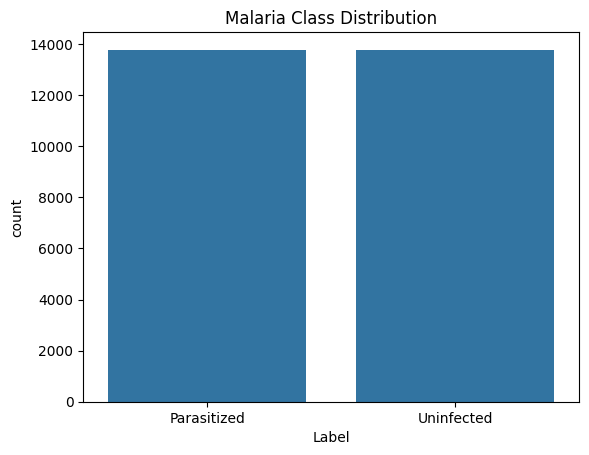

In [6]:
sns.countplot(
    x="Label",
    data=df
)

plt.title("Malaria Class Distribution")

plt.show()

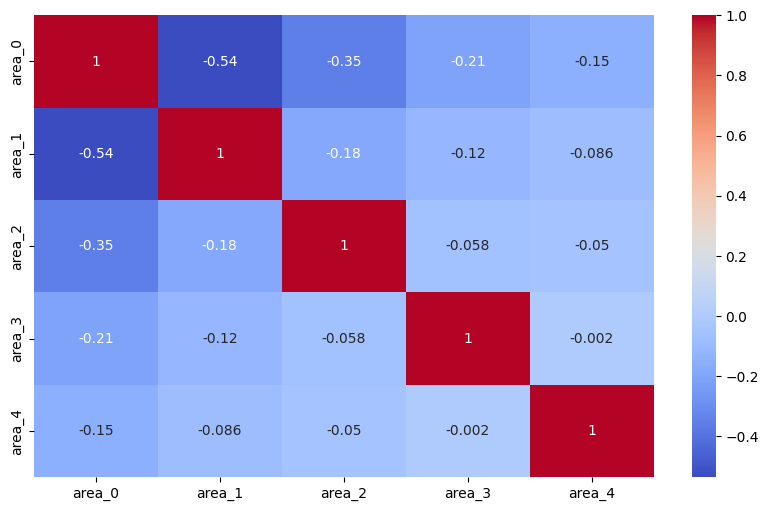

In [7]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

## Encode Target Variable

In [8]:
# Convert Labels

df["Label"] = df["Label"].map({
    "Parasitized":1,
    "Uninfected":0
})

## Feature Selection

In [9]:
X = df.drop(
    "Label",
    axis=1
)

y = df["Label"]

## Split Dataset

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Shape :", X_train.shape)

print("Testing Shape :", X_test.shape)

Training Shape : (22046, 5)
Testing Shape : (5512, 5)


## Train Model

In [11]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(
    X_train,
    y_train
)

print("Model Trained Successfully")

Model Trained Successfully


## Make Predictions

In [12]:
y_pred = model.predict(
    X_test
)

print(y_pred[:10])

[1 1 0 0 0 0 1 1 1 0]


## Evaluate Model

In [13]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy :", accuracy)

Accuracy : 0.8682873730043541


In [14]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.88      0.85      0.86      2715
           1       0.86      0.88      0.87      2797

    accuracy                           0.87      5512
   macro avg       0.87      0.87      0.87      5512
weighted avg       0.87      0.87      0.87      5512



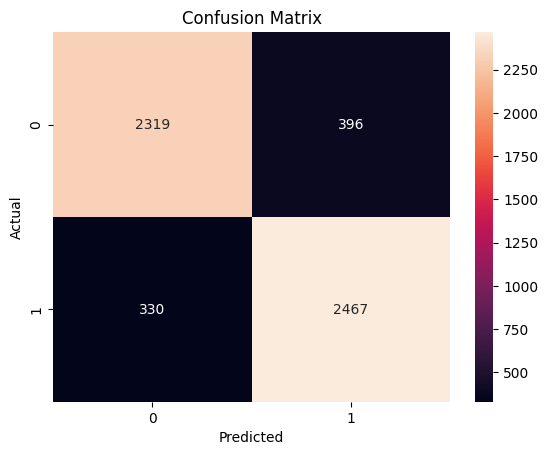

In [15]:
cm = confusion_matrix(
    y_test,
    y_pred
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

## Predict New Sample

In [16]:
sample = [[
    175.5,
    126,
    131,
    8902.5,
    0
]]

prediction = model.predict(sample)

if prediction[0] == 1:

    print("Malaria Detected")

else:

    print("No Malaria Detected")

Malaria Detected


c:\Users\dell\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


# Conclusion

The Malaria Detection System successfully classifies blood sample data into infected and uninfected categories.

Algorithm Used:
- Random Forest Classifier

Benefits:
- Early Detection
- Fast Diagnosis
- Improved Healthcare Support

The model demonstrates how Machine Learning can assist medical professionals in disease detection.